In [1]:
import sys
!{sys.executable} -m pip install plotly cufflinks

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sys
!{sys.executable} -m pip install --user plotly cufflinks

In [3]:
import seaborn as sns
import pandas as pd
import cufflinks as cf
from plotly.offline import iplot

In [4]:
tips = sns.load_dataset("tips")

In [5]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


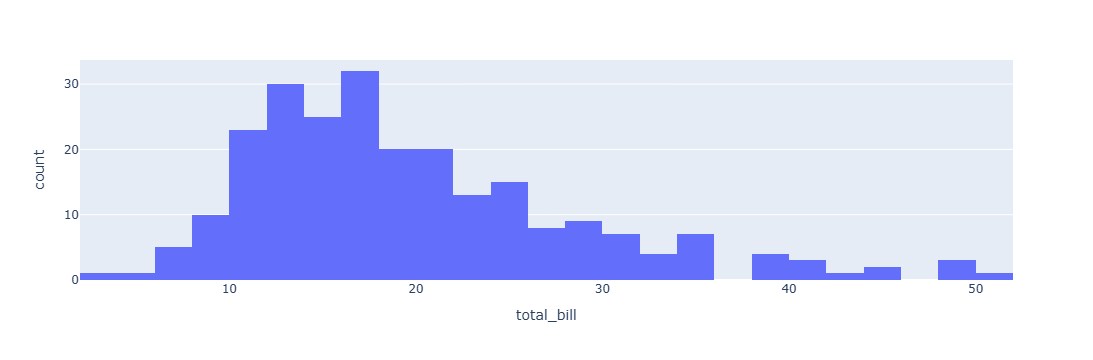

In [8]:
import plotly.express as px

fig = px.histogram(tips, x='total_bill')
fig.show()

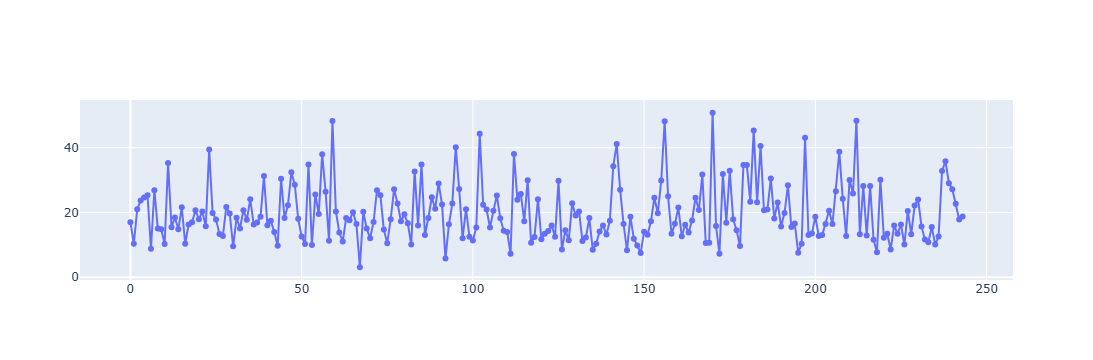

In [9]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=tips['total_bill'],
        mode='lines+markers'
    )
)

fig.show()

C:\Users\Windows11\AppData\Local\Temp\ipykernel_15128\923013695.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



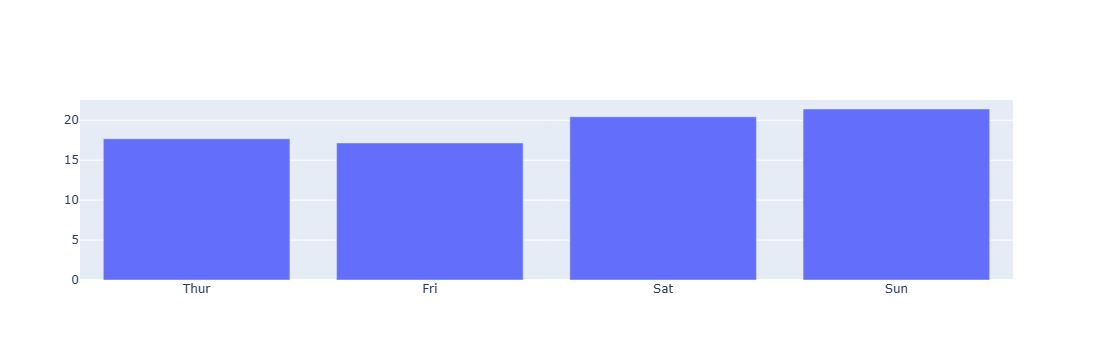

In [11]:

data = tips.groupby('day')['total_bill'].mean()

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=data.index,
        y=data.values
    )
)
fig.show()

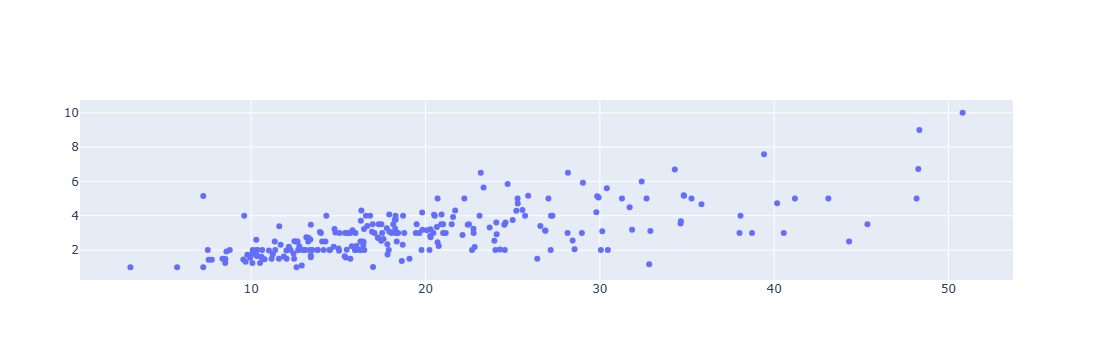

In [17]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=tips['total_bill'],
        y=tips['tip'],
        mode='markers'
    )
)

fig.show()

In [19]:
tips[['total_bill','day']].iplot(kind= 'box',x = 'total_bill',y = 'day')

ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of box.marker
        Received value: 'rgba(255, 153, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list

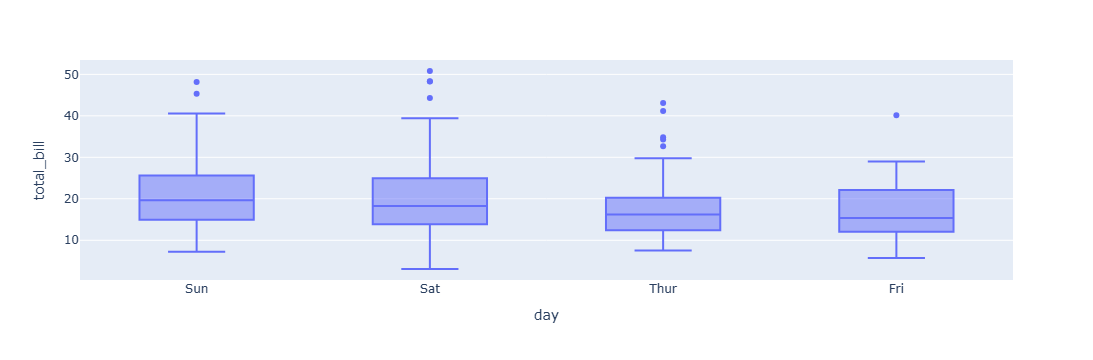

In [20]:
import plotly.express as px

fig = px.box(
    tips,
    x='day',
    y='total_bill'
)

fig.show()

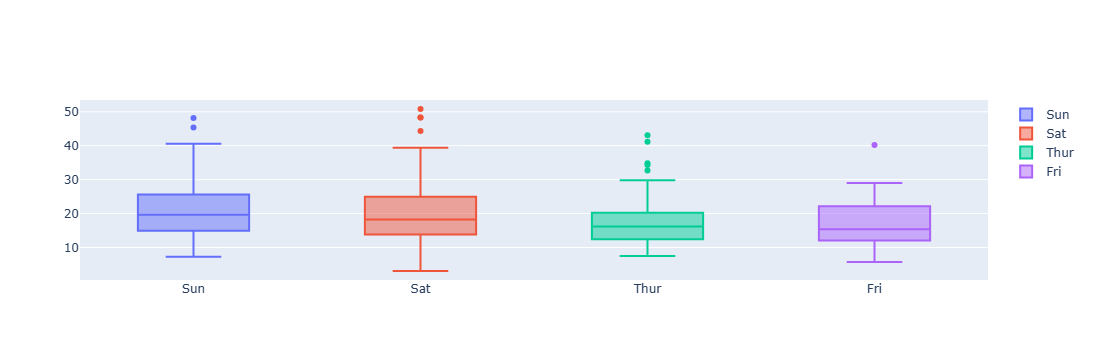

In [21]:
import plotly.graph_objects as go

fig = go.Figure()

for day in tips['day'].unique():
    data = tips[tips['day'] == day]

    fig.add_trace(
        go.Box(
            y=data['total_bill'],
            name=day
        )
    )

fig.show()
